In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

In [2]:
df = pd.read_csv("./loan_approval.csv")

## 1. Understanding the Dataset

In [3]:
df.shape

(4000, 11)

In [4]:
df.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'CreditHistory', 'Dependents', 'Education',
       'EmploymentType', 'PropertyArea', 'MaritalStatus', 'Loan_Status'],
      dtype='str')

In [5]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Dependents,Education,EmploymentType,PropertyArea,MaritalStatus,Loan_Status
0,136958,50772,298430,300,1,2,Not Graduate,Self Employed,Semiurban,Single,1
1,146932,72084,205887,120,0,1,Graduate,Salaried,Semiurban,Married,1
2,118694,40149,265572,180,1,3+,Graduate,Self Employed,Rural,Single,1
3,134879,27526,144348,36,1,0,Not Graduate,Self Employed,Urban,Single,1
4,125268,68477,155736,240,1,3+,Not Graduate,Self Employed,Urban,Single,1


In [6]:
df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
CreditHistory        0
Dependents           0
Education            0
EmploymentType       0
PropertyArea         0
MaritalStatus        0
Loan_Status          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ApplicantIncome    4000 non-null   int64
 1   CoapplicantIncome  4000 non-null   int64
 2   LoanAmount         4000 non-null   int64
 3   Loan_Amount_Term   4000 non-null   int64
 4   CreditHistory      4000 non-null   int64
 5   Dependents         4000 non-null   str  
 6   Education          4000 non-null   str  
 7   EmploymentType     4000 non-null   str  
 8   PropertyArea       4000 non-null   str  
 9   MaritalStatus      4000 non-null   str  
 10  Loan_Status        4000 non-null   int64
dtypes: int64(6), str(5)
memory usage: 343.9 KB


In [9]:
df["Loan_Status"].value_counts()

Loan_Status
1    3347
0     653
Name: count, dtype: int64

In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Loan_Status
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000
mean,82404.366000,39191.448500,274527.928500,130.887000,0.754500,0.83675
std,39198.475219,23315.772335,128765.760647,96.149656,0.430437,0.36964
min,15126.000000,2.000000,50015.000000,12.000000,0.000000,0.00000
25%,48217.750000,19071.000000,163228.000000,60.000000,1.000000,1.00000
50%,82401.000000,38617.000000,276918.000000,120.000000,1.000000,1.00000
75%,116021.750000,59256.750000,384040.750000,240.000000,1.000000,1.00000
max,149869.000000,79980.000000,499998.000000,300.000000,1.000000,1.00000


In [75]:
dfcopy = df.copy()

## 2. Outlier analysis

In [76]:
numeric_columns = dfcopy.select_dtypes(include='number')

In [77]:
categorical_columns = dfcopy.select_dtypes(include='str')

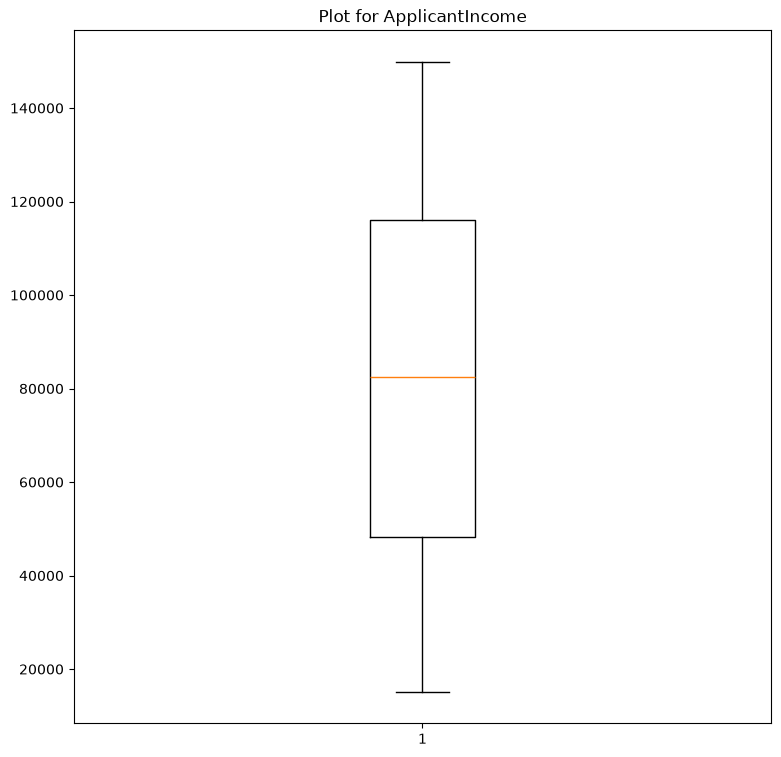

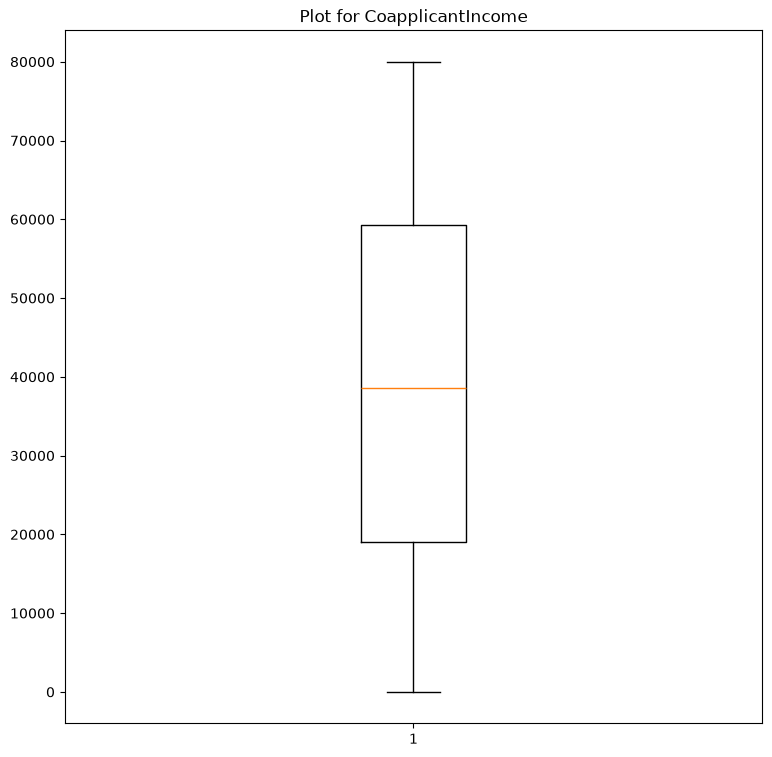

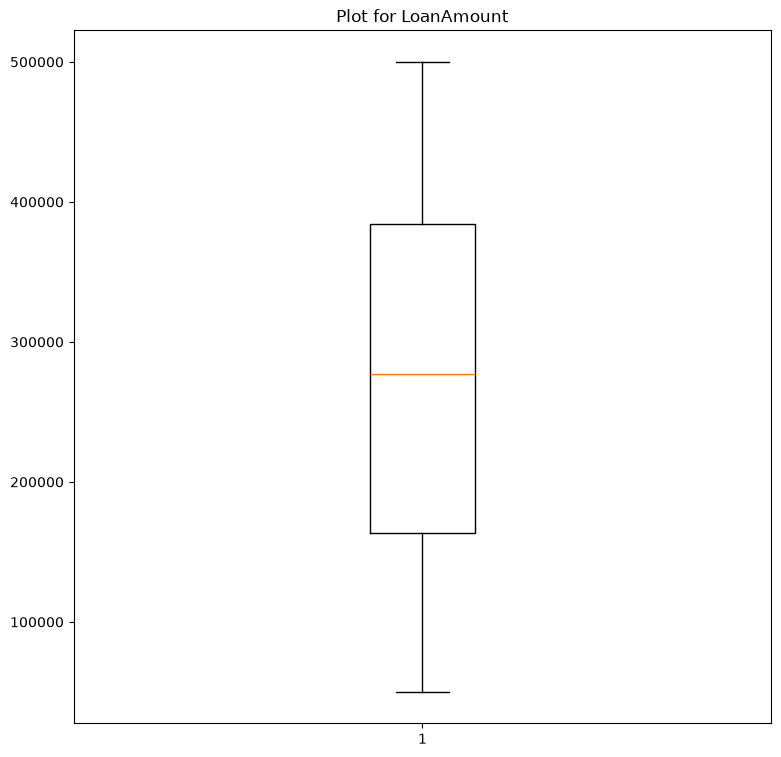

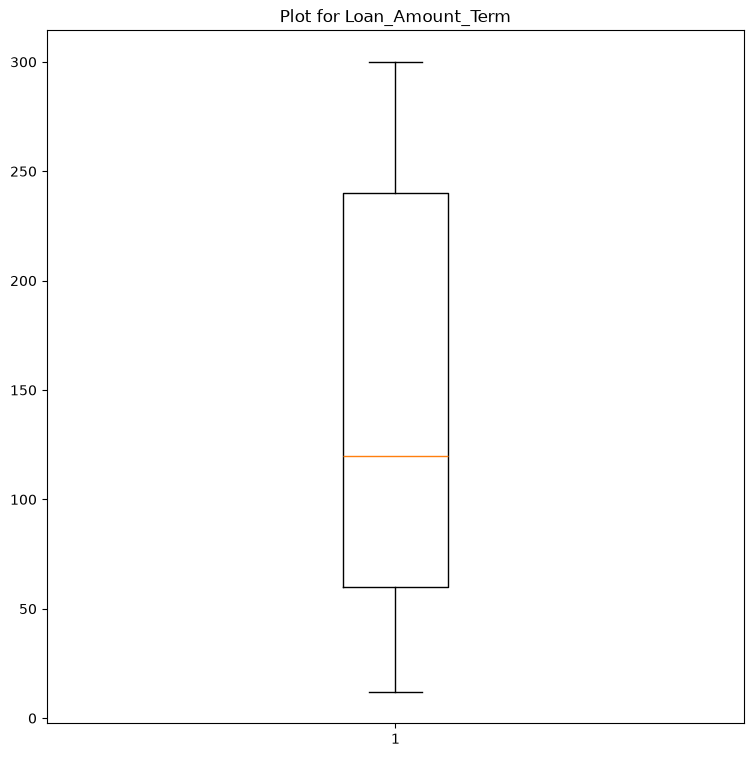

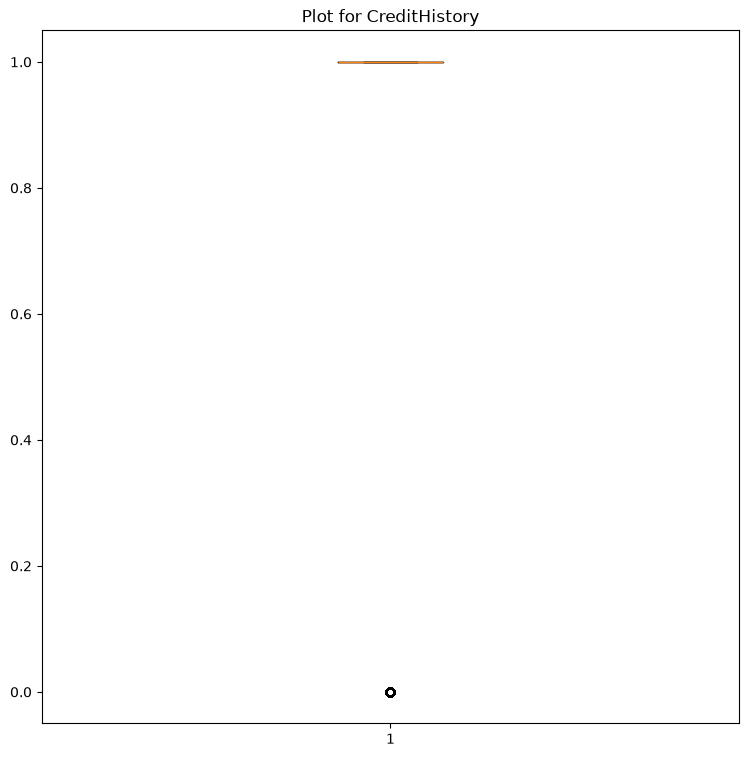

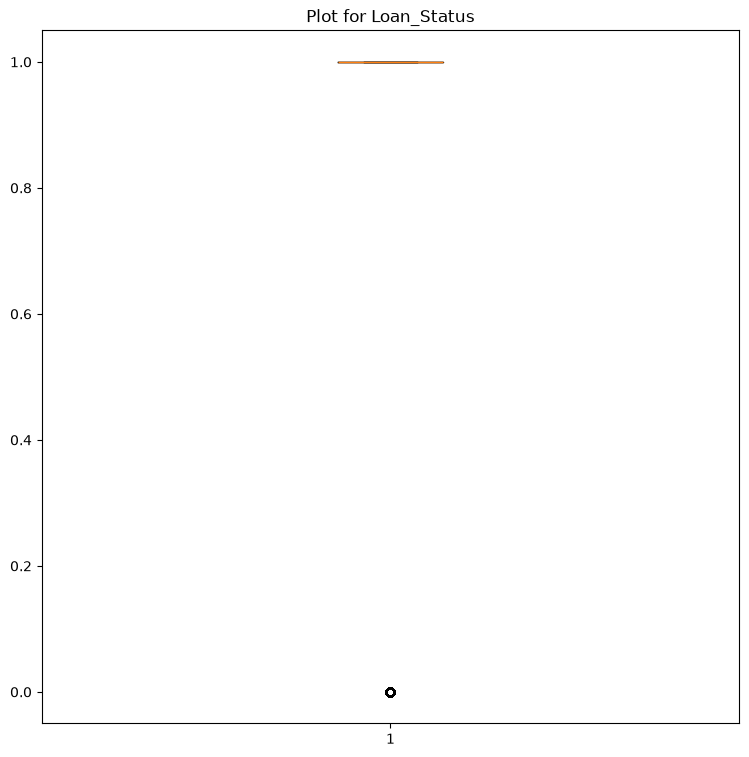

In [78]:
for col in numeric_columns:
    plt.figure(figsize=(9,9))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"Plot for {col}")
    plt.show()

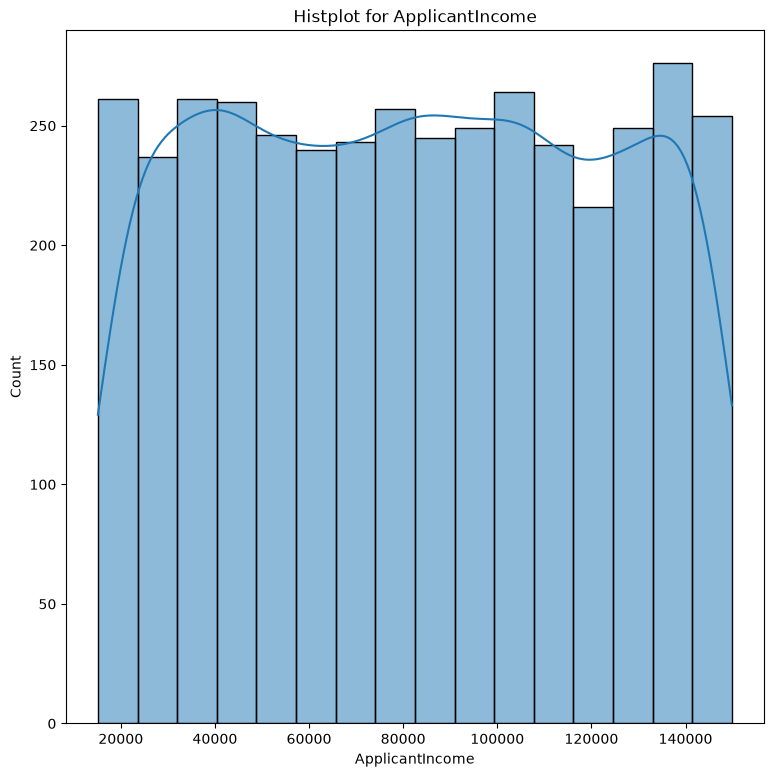

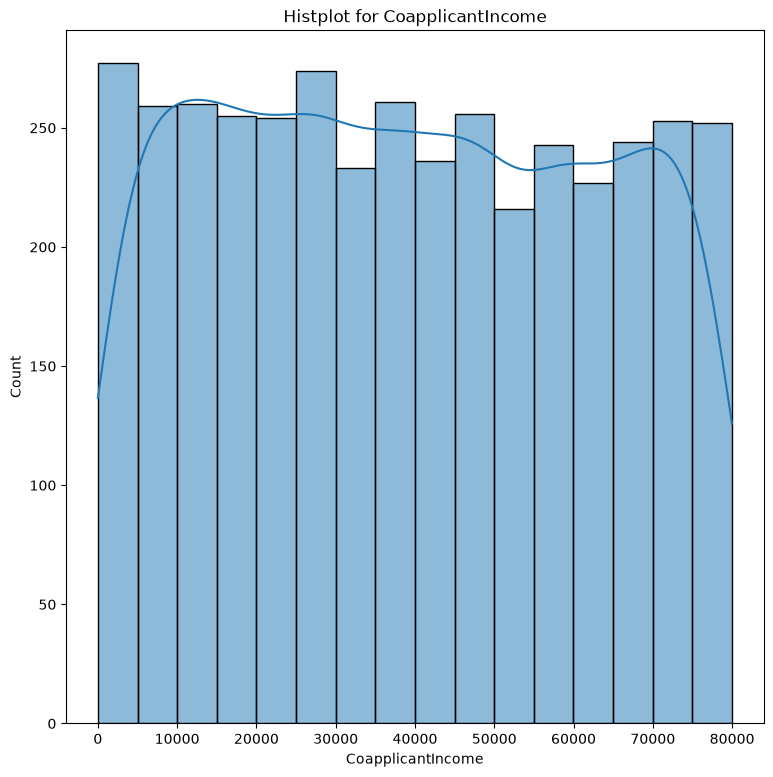

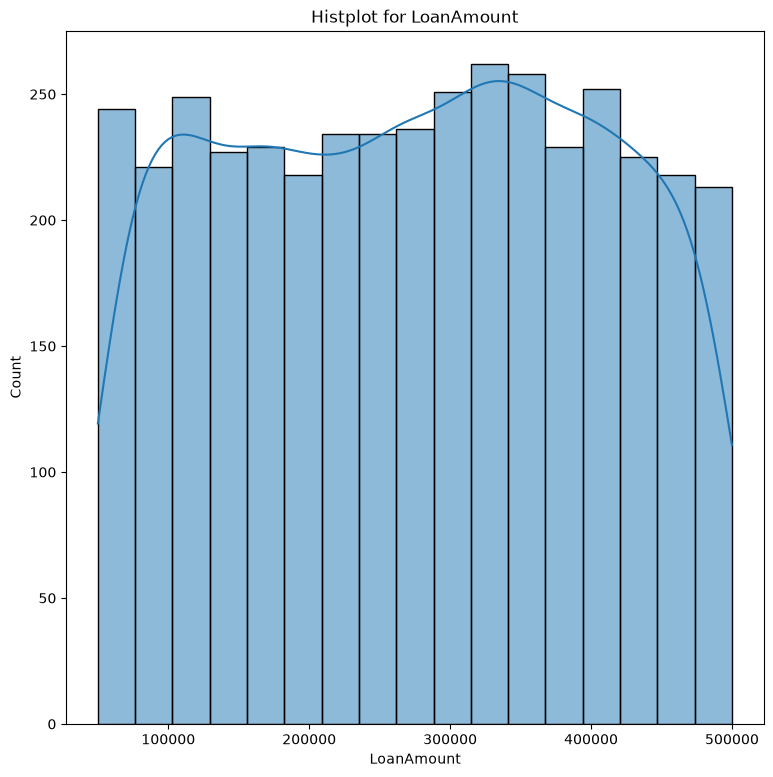

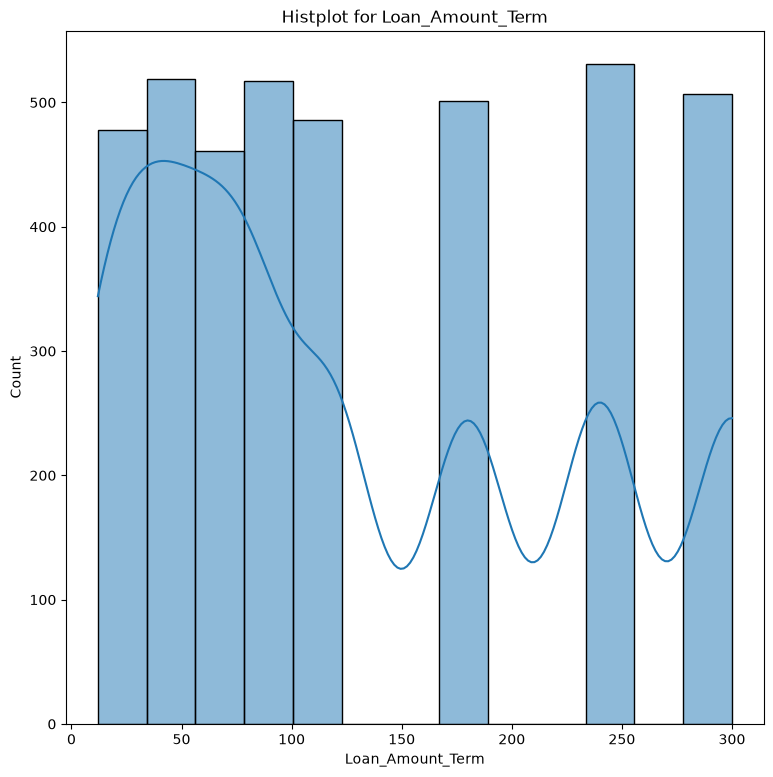

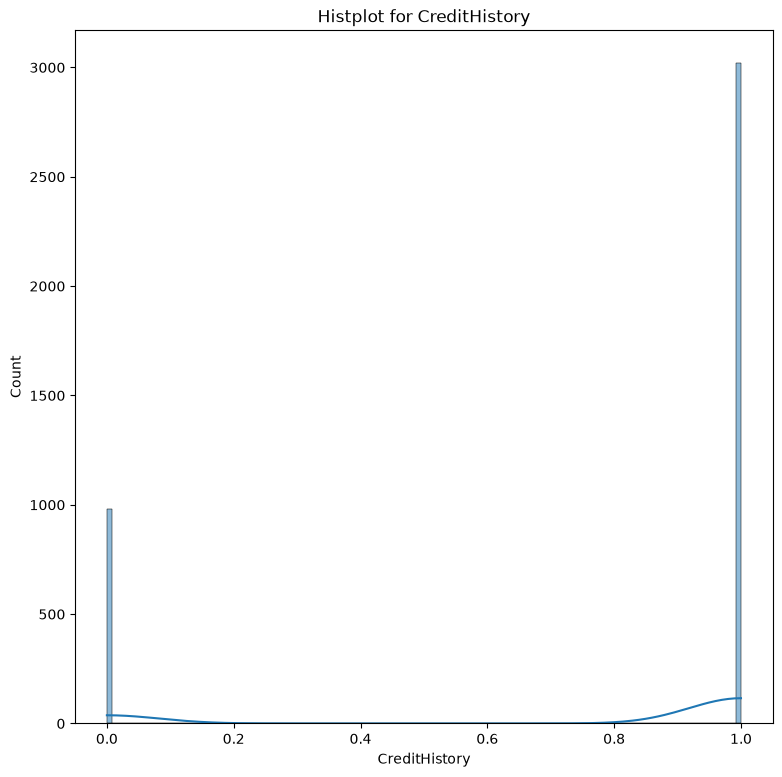

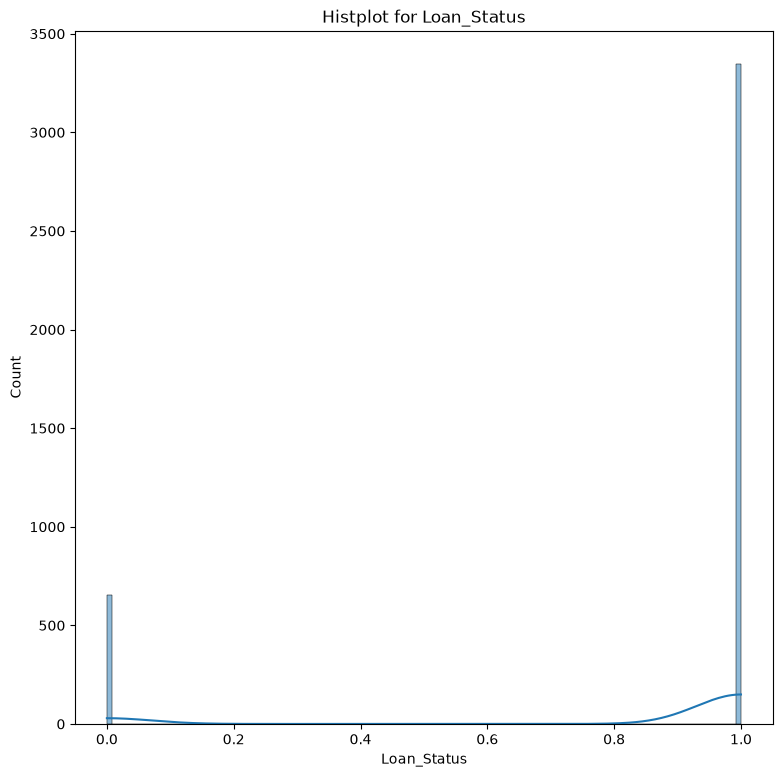

In [79]:
for col in numeric_columns:
    plt.figure(figsize=(9,9))
    sns.histplot(dfcopy[col], kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

No possible outliers visible, the data is distributed normally and based on the analysis is mostly synthetic. Using z-score method to check for the outliers

In [80]:
def zscore_series(s: pd.Series):
    s = s.dropna()
    return (s - s.mean()) / s.std(ddof=0)

z_counts = {}

for col in numeric_columns:
    z = zscore_series(dfcopy[col])
    z_counts[col] = int((np.abs(z) > 3).sum())

pd.DataFrame({ "Z score counts": z_counts })

,Z score counts
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
CreditHistory,0
Loan_Status,0


No possible outliers found

## 3. Correlation analysis

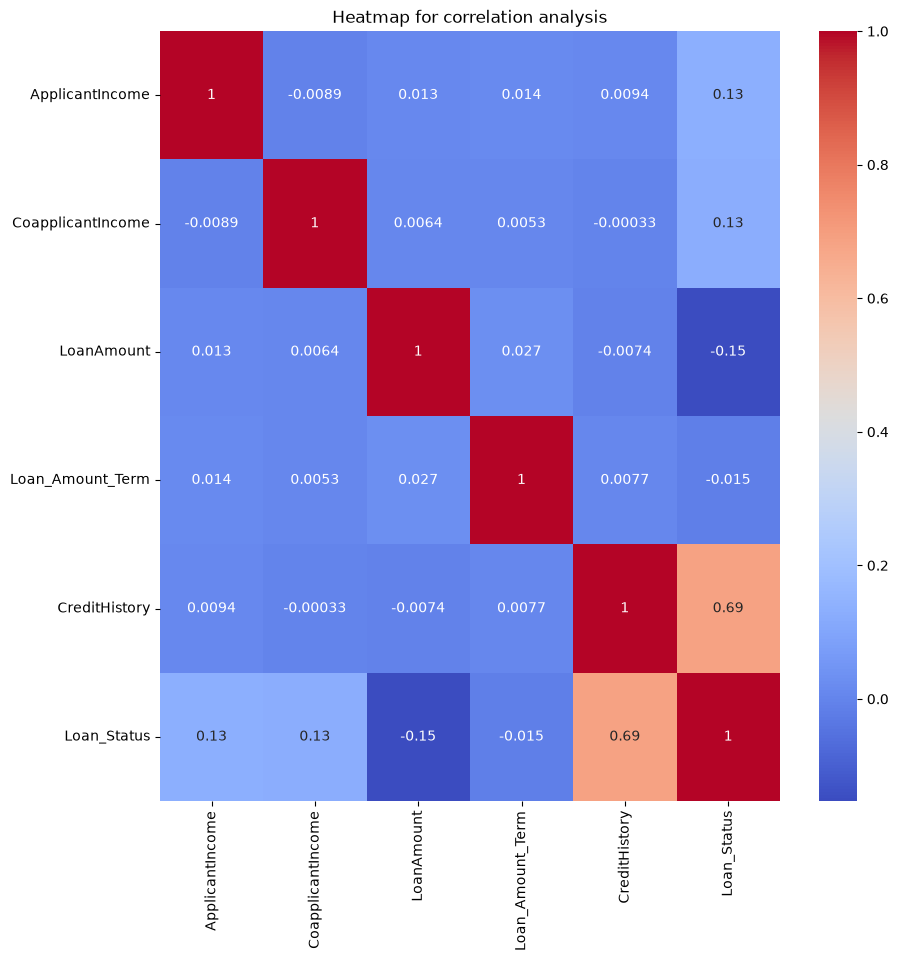

In [81]:
corr = numeric_columns.corr()

plt.figure(figsize=(10,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for correlation analysis")
plt.show()

Only one significant relation is present other than that no viable relations are present

## 4. Encoding the categorical columns

In [82]:
categorical_columns.columns

Index(['Dependents', 'Education', 'EmploymentType', 'PropertyArea',
       'MaritalStatus'],
      dtype='str')

Label encoding the 
- Employment type
- marital status 
- education

columns because they have binary values and the rest of the columns
- dependents
- property area

will be encoded by one hot encoding because they have multiple values and the values are not having any specific order.

#### Label encoding

In [83]:
le = LabelEncoder()

dfcopy["EmploymentType"] = le.fit_transform(dfcopy["EmploymentType"])

dfcopy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Dependents,Education,EmploymentType,PropertyArea,MaritalStatus,Loan_Status
0,136958,50772,298430,300,1,2,Not Graduate,1,Semiurban,Single,1
1,146932,72084,205887,120,0,1,Graduate,0,Semiurban,Married,1
2,118694,40149,265572,180,1,3+,Graduate,1,Rural,Single,1
3,134879,27526,144348,36,1,0,Not Graduate,1,Urban,Single,1
4,125268,68477,155736,240,1,3+,Not Graduate,1,Urban,Single,1


In [84]:
dfcopy["MaritalStatus"] = le.fit_transform(dfcopy["MaritalStatus"])

dfcopy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Dependents,Education,EmploymentType,PropertyArea,MaritalStatus,Loan_Status
0,136958,50772,298430,300,1,2,Not Graduate,1,Semiurban,1,1
1,146932,72084,205887,120,0,1,Graduate,0,Semiurban,0,1
2,118694,40149,265572,180,1,3+,Graduate,1,Rural,1,1
3,134879,27526,144348,36,1,0,Not Graduate,1,Urban,1,1
4,125268,68477,155736,240,1,3+,Not Graduate,1,Urban,1,1


In [85]:
dfcopy["Education"] = le.fit_transform(dfcopy["Education"])

dfcopy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Dependents,Education,EmploymentType,PropertyArea,MaritalStatus,Loan_Status
0,136958,50772,298430,300,1,2,1,1,Semiurban,1,1
1,146932,72084,205887,120,0,1,0,0,Semiurban,0,1
2,118694,40149,265572,180,1,3+,0,1,Rural,1,1
3,134879,27526,144348,36,1,0,1,1,Urban,1,1
4,125268,68477,155736,240,1,3+,1,1,Urban,1,1


#### One hot encoding

In [86]:
one_hot_columns = categorical_columns.drop(columns=["EmploymentType", "MaritalStatus", "Education"])

In [87]:
one_hot_columns.head()

,Dependents,PropertyArea
0,2,Semiurban
1,1,Semiurban
2,3+,Rural
3,0,Urban
4,3+,Urban


In [88]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [89]:
encoder_array = encoder.fit_transform(dfcopy[one_hot_columns.columns])

In [90]:
encoded_columns = encoder.get_feature_names_out(one_hot_columns.columns)

In [91]:
encoded_df = pd.DataFrame(
    encoder_array,
    columns=encoded_columns,
    index=dfcopy.index
)

In [92]:
dfcopy = dfcopy.drop(columns=["Dependents", "PropertyArea"])

In [93]:
dfcopy = pd.concat([dfcopy, encoded_df], axis=1)

In [94]:
dfcopy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Education,EmploymentType,MaritalStatus,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,PropertyArea_Rural,PropertyArea_Semiurban,PropertyArea_Urban
0,136958,50772,298430,300,1,1,1,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,146932,72084,205887,120,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,118694,40149,265572,180,1,0,1,1,1,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,134879,27526,144348,36,1,1,1,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,125268,68477,155736,240,1,1,1,1,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## 5. Preparing the data for training the model

In [95]:
X = dfcopy.drop("Loan_Status", axis=1)
y = dfcopy["Loan_Status"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3200, 15)
(800, 15)
(3200,)
(800,)


## 6. Training the Decision Tree model form the data

In [110]:
decision_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=10,
    min_samples_leaf=6,
    min_samples_split=12
)

decision_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

##  7. Checking the decision tree metrics

In [111]:
decision_prediction = decision_model.predict(X_test)
decision_prediction_probablity = decision_model.predict_proba(X_test)[:,1]

print("Accuracy score: ", accuracy_score(y_test, decision_prediction))

print("\n ROC AUC score: ", roc_auc_score(y_test, decision_prediction_probablity))

cm = confusion_matrix(y_test, decision_prediction)
print("\n Confusion Matrix: \n", cm)

print("\n Classification report: \n ", classification_report(y_test, decision_prediction))

Accuracy score:  0.9425

 ROC AUC score:  0.9778186527933477

 Confusion Matrix: 
 [[139   0]
 [ 46 615]]

 Classification report: 
                precision    recall  f1-score   support

           0       0.75      1.00      0.86       139
           1       1.00      0.93      0.96       661

    accuracy                           0.94       800
   macro avg       0.88      0.97      0.91       800
weighted avg       0.96      0.94      0.95       800



## 8. Training Random Forest model form the data

In [131]:
forest_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    bootstrap=True,
    n_estimators=700,
    max_features='sqrt',
    max_depth=10,
    min_samples_leaf=6,
    min_samples_split=12
)

forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

## 9. Testing the random forest model metrics

In [132]:
forest_prediction = forest_model.predict(X_test)
forest_prediction_probablity = forest_model.predict_proba(X_test)[:,1]

print("Accuracy score: ", accuracy_score(y_test, forest_prediction))

print("\n ROC AUC score: ", roc_auc_score(y_test, forest_prediction_probablity))

cm = confusion_matrix(y_test, forest_prediction)
print("\n Confusion Matrix: \n", cm)

print("\n Classification report: \n ", classification_report(y_test, forest_prediction))

Accuracy score:  0.935

 ROC AUC score:  0.9781342853100273

 Confusion Matrix: 
 [[138   1]
 [ 51 610]]

 Classification report: 
                precision    recall  f1-score   support

           0       0.73      0.99      0.84       139
           1       1.00      0.92      0.96       661

    accuracy                           0.94       800
   macro avg       0.86      0.96      0.90       800
weighted avg       0.95      0.94      0.94       800



In [133]:
dfcopy.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Education,EmploymentType,MaritalStatus,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,PropertyArea_Rural,PropertyArea_Semiurban,PropertyArea_Urban
0,136958,50772,298430,300,1,1,1,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,146932,72084,205887,120,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,118694,40149,265572,180,1,0,1,1,1,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,134879,27526,144348,36,1,1,1,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,125268,68477,155736,240,1,1,1,1,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [134]:
dfcopy.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Education,EmploymentType,MaritalStatus,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,PropertyArea_Rural,PropertyArea_Semiurban,PropertyArea_Urban
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,82404.366000,39191.448500,274527.928500,130.887000,0.754500,0.492000,0.502000,0.497250,0.83675,0.237000,0.263000,0.245000,0.255000,0.310750,0.337500,0.351750
std,39198.475219,23315.772335,128765.760647,96.149656,0.430437,0.499998,0.500059,0.500055,0.36964,0.425295,0.440317,0.430141,0.435916,0.462859,0.472916,0.477576
min,15126.000000,2.000000,50015.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48217.750000,19071.000000,163228.000000,60.000000,1.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,82401.000000,38617.000000,276918.000000,120.000000,1.000000,0.000000,1.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,116021.750000,59256.750000,384040.750000,240.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,149869.000000,79980.000000,499998.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 10. Testing the prediction of both the models

In [136]:
df_predict_approved = pd.DataFrame({
    'ApplicantIncome': [140000, 125000, 135000],
    'CoapplicantIncome': [65000, 70000, 50000],
    'LoanAmount': [150000, 120000, 180000],
    'Loan_Amount_Term': [120, 180, 240],
    'CreditHistory': [1, 1, 1],
    'Education': [1, 1, 1],          # Assuming 1 is Graduate
    'EmploymentType': [1, 1, 0],     # Assuming 1 is employed/salaried
    'MaritalStatus': [1, 1, 0],      # Assuming 1 is married
    'Dependents_0': [1.0, 0.0, 1.0],
    'Dependents_1': [0.0, 1.0, 0.0],
    'Dependents_2': [0.0, 0.0, 0.0],
    'Dependents_3+': [0.0, 0.0, 0.0],
    'PropertyArea_Rural': [0.0, 0.0, 0.0],
    'PropertyArea_Semiurban': [1.0, 0.0, 1.0],
    'PropertyArea_Urban': [0.0, 1.0, 0.0]
})

predict_decision = decision_model.predict(df_predict_approved)
predict_forest = forest_model.predict(df_predict_approved)

print("Decision tree prediction: ", predict_decision)
print("\nRandom forest prediction: ", predict_forest)

Decision tree prediction:  [1 1 1]

Random forest prediction:  [1 1 1]


In [137]:
df_predict_rejected = pd.DataFrame({
    'ApplicantIncome': [18000, 25000, 20000],
    'CoapplicantIncome': [5000, 2000, 1000],
    'LoanAmount': [450000, 480000, 490000],
    'Loan_Amount_Term': [300, 300, 300],
    'CreditHistory': [0, 0, 0],
    'Education': [0, 0, 0],          # Assuming 0 is Not Graduate
    'EmploymentType': [0, 0, 0],
    'MaritalStatus': [0, 0, 0],
    'Dependents_0': [0.0, 0.0, 0.0],
    'Dependents_1': [0.0, 0.0, 0.0],
    'Dependents_2': [0.0, 1.0, 0.0],
    'Dependents_3+': [1.0, 0.0, 1.0],
    'PropertyArea_Rural': [1.0, 1.0, 1.0],
    'PropertyArea_Semiurban': [0.0, 0.0, 0.0],
    'PropertyArea_Urban': [0.0, 0.0, 0.0]
})

predict_decision = decision_model.predict(df_predict_rejected)
predict_forest = forest_model.predict(df_predict_rejected)

print("Decision tree prediction: ", predict_decision)
print("\nRandom forest prediction: ", predict_forest)

Decision tree prediction:  [0 0 0]

Random forest prediction:  [0 0 0]


In [138]:
df_out_of_scope = pd.DataFrame({
    'ApplicantIncome': [np.nan, 9999999, -50000],
    'CoapplicantIncome': [50000, np.nan, -1000],
    'LoanAmount': [200000, 200000, np.nan],
    'Loan_Amount_Term': [-12, 1000, np.nan],
    'CreditHistory': [1, 5, np.nan], # Credit history should be 0 or 1
    'Education': [1, np.nan, 1],
    'EmploymentType': [np.nan, 1, 0],
    'MaritalStatus': [1, 1, np.nan],
    # Broken one-hot encoding (multiple true values or all false for a category)
    'Dependents_0': [1.0, 1.0, 0.0],
    'Dependents_1': [1.0, 0.0, 0.0],
    'Dependents_2': [0.0, 1.0, 0.0],
    'Dependents_3+': [0.0, 0.0, 0.0],
    'PropertyArea_Rural': [1.0, 0.0, np.nan],
    'PropertyArea_Semiurban': [1.0, 0.0, np.nan],
    'PropertyArea_Urban': [1.0, 0.0, np.nan]
})

predict_decision = decision_model.predict(df_out_of_scope)
predict_forest = forest_model.predict(df_out_of_scope)

print("Decision tree prediction: ", predict_decision)
print("\nRandom forest prediction: ", predict_forest)

Decision tree prediction:  [1 1 0]

Random forest prediction:  [1 1 0]


## 11. Visualization of all the column importance in each model

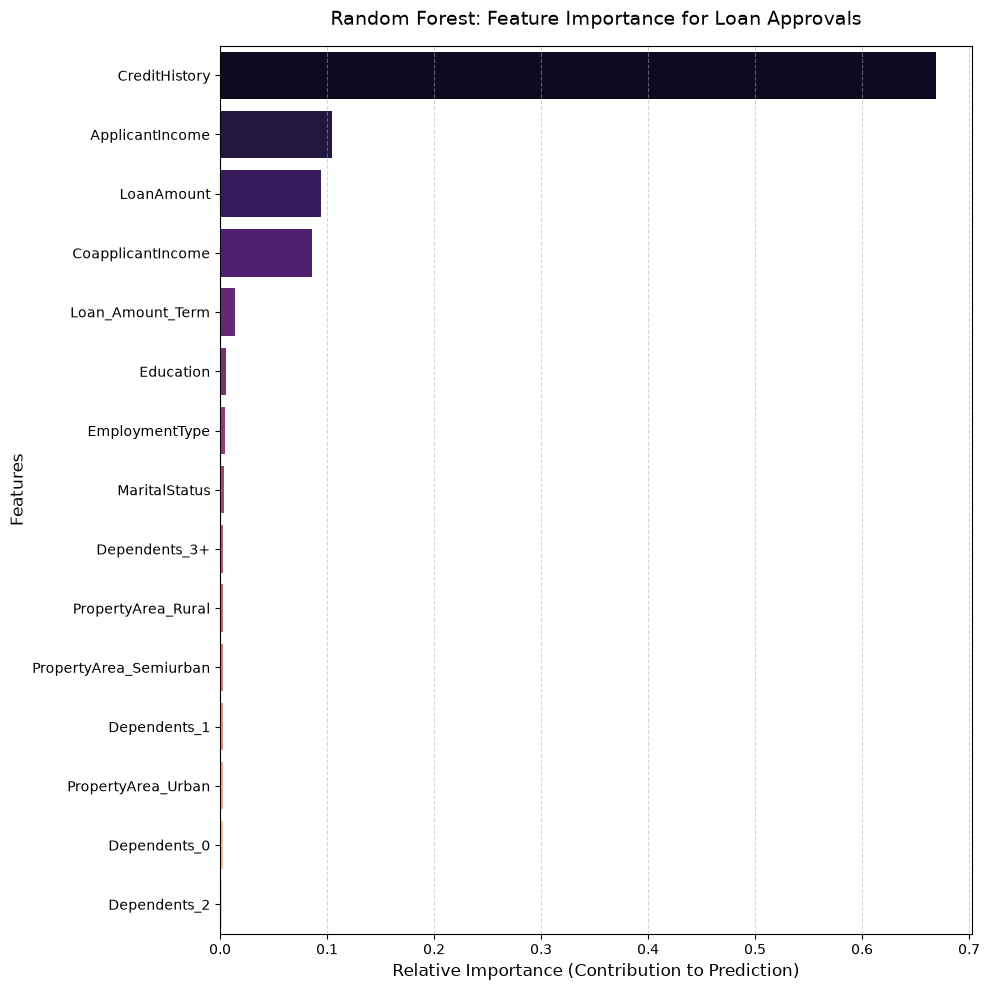

In [142]:
importances = forest_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    hue='Feature',
    palette='magma', 
    legend=False
)

plt.title('Random Forest: Feature Importance for Loan Approvals', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

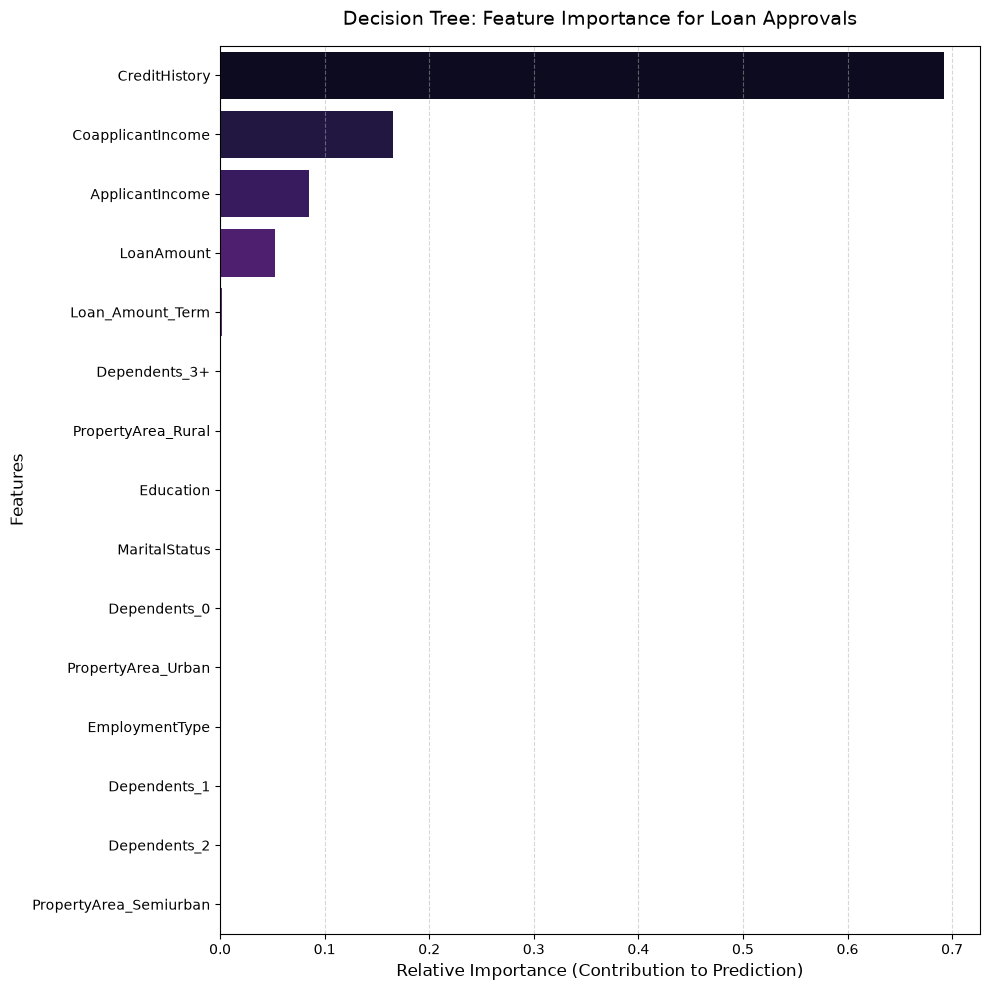

In [143]:
importances = decision_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    hue='Feature',
    palette='magma', 
    legend=False
)

plt.title('Decision Tree: Feature Importance for Loan Approvals', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 12. Visualization of comparison of both the models.

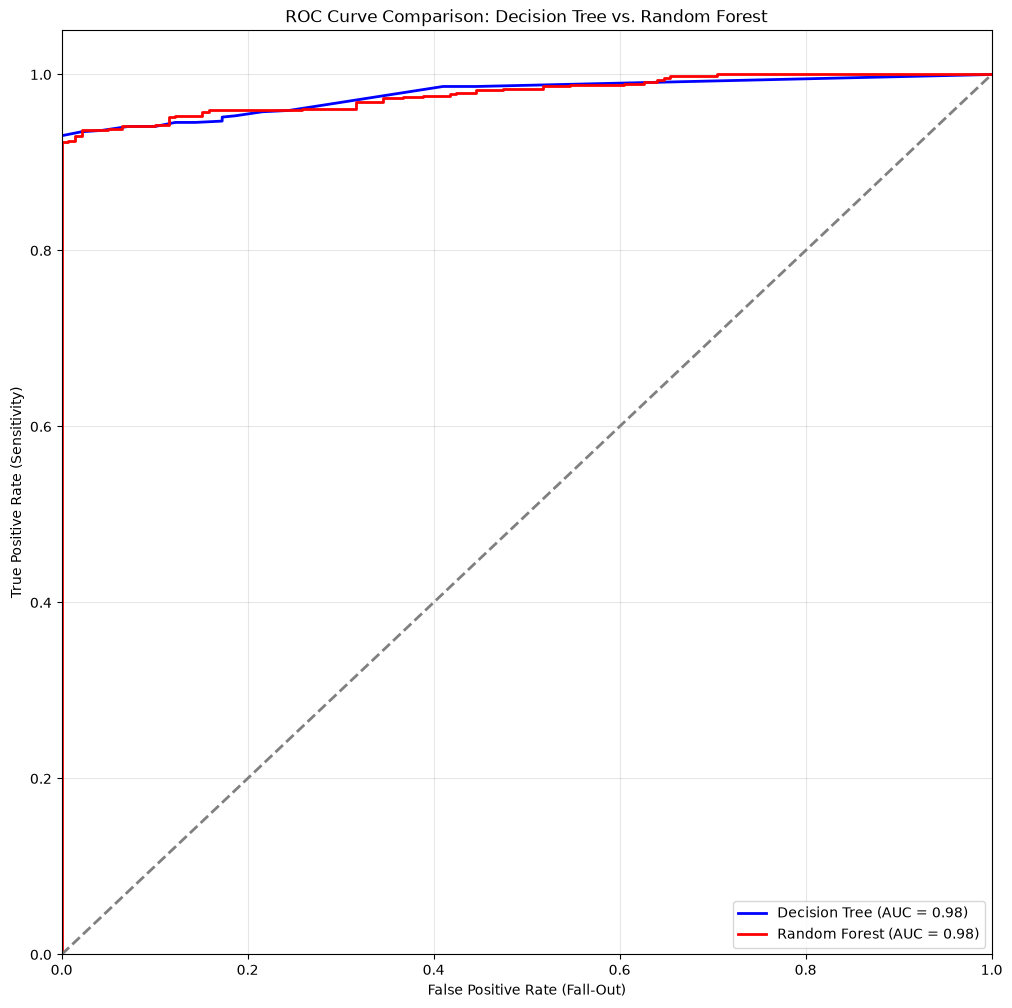

In [146]:
from sklearn.metrics import roc_curve, auc

# Calculate False Positive Rates, True Positive Rates, and AUC for both
fpr_dt, tpr_dt, _ = roc_curve(y_test, decision_prediction_probablity)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, forest_prediction_probablity)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotting the ROC Curves
plt.figure(figsize=(12, 12))

# Decision Tree Line
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, 
         label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# Random Forest Line
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, 
         label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Baseline (Random Guessing)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison: Decision Tree vs. Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

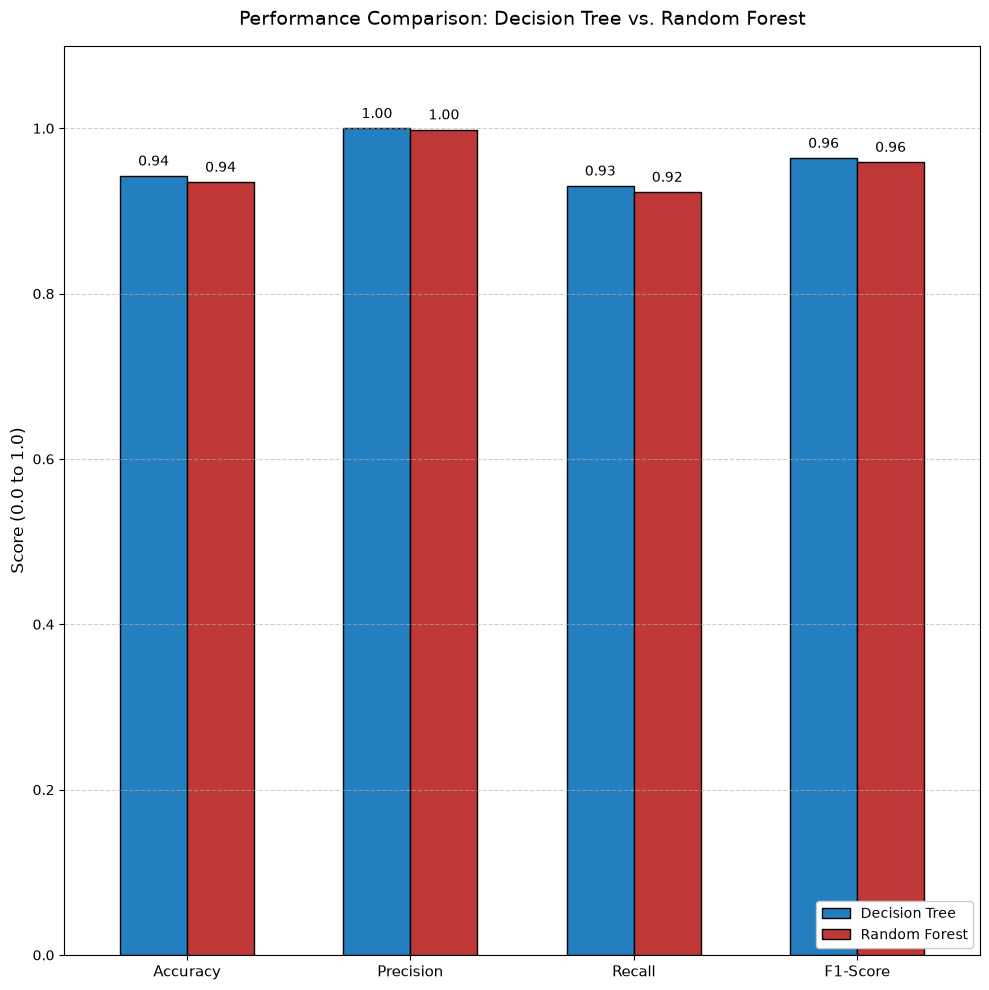

In [147]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_metrics = [
    accuracy_score(y_test, decision_prediction),
    precision_score(y_test, decision_prediction),
    recall_score(y_test, decision_prediction),
    f1_score(y_test, decision_prediction)
]

rf_metrics = [
    accuracy_score(y_test, forest_prediction),
    precision_score(y_test, forest_prediction),
    recall_score(y_test, forest_prediction),
    f1_score(y_test, forest_prediction)
]

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics
})

metrics_df.set_index('Metric', inplace=True)

ax = metrics_df.plot(
    kind='bar', 
    figsize=(10, 10), 
    color=["#247FC0", "#c03737"], # Blue for DT, Red for RF
    edgecolor='black',
    width=0.6
)

plt.title('Performance Comparison: Decision Tree vs. Random Forest', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 1.1) 
plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='lower right', framealpha=1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()